# Executive Summary

This notebook explores the structure of the Dutch labour market across industries using CBS dataset **85919NED**, which provides information on employment, compensation, working hours, and job composition by sector from **1995 to 2024**.

The exploratory analysis highlights major differences between sectors in terms of employment size, wage levels, working time, and the prevalence of part-time work. Large service sectors such as healthcare, trade, and business services dominate employment, while knowledge-intensive sectors such as finance and ICT exhibit higher compensation levels.

The results also show that part-time work is strongly concentrated in service-oriented sectors, particularly healthcare, hospitality, and education. In contrast, sectors such as construction, manufacturing, and transport rely more heavily on full-time employment and exhibit higher average working hours.

Overall, the analysis provides a structural overview of labour market characteristics across industries and helps identify key sectoral differences that may influence labour market outcomes.

# Cleaning 85919NED Data



## 1. Import required libraries

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Reading the table from Silver Database

In [2]:
from pathlib import Path
import sqlite3
import pandas as pd

# Path to the silver database
db_path = Path("../data/2_silver/silver_data.db")

# Connect to the database
conn = sqlite3.connect(db_path)
print(f"Connected to {db_path}")

# List available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print("Available tables:", tables["name"].tolist())

# Read the table (IMPORTANT: quote table name because it starts with a number)
table_name = "85919NED_silver"

df_85919NED = pd.read_sql_query(
    f'SELECT * FROM "{table_name}"',
    conn
)

print(f"Loaded {len(df_85919NED)} rows from {table_name}")
display(df_85919NED.head())

# 1️⃣ Column names
print(df_85919NED.columns.tolist())

# 2️⃣ Data types
print(df_85919NED.dtypes)

# 3️⃣ Compact summary (best overview)
df_85919NED.info()

# 5️⃣ Unique values per column (optional but useful)
for col in df_85919NED.columns:
    print(f"\n{col}:")
    print(df_85919NED[col].unique()[:10])

Connected to ..\data\2_silver\silver_data.db
Available tables: ['85920NED_silver_SH', '85916NED_silver_SH', '85918NED_silver_SH', '85918NED_silver', '85919NED_silver', '85920NED_silver', '85916NED_silver']
Loaded 3000 rows from 85919NED_silver


,silver_id,bronze_pk,ID,BedrijfstakkenBranchesSBI2008,Perioden,BeloningVanWerknemers_1,Lonen_2,SocialePremiesTLVWerkgevers_3,Loonkosten_4,BeloningVanWerknemers_5,...,Mannen_34,Vrouwen_35,Totaal_36,_source_file,BedrijfstakkenBranchesSBI2008_Title,BedrijfstakkenBranchesSBI2008_Description,BedrijfstakkenBranchesSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status
0,1,TypedDataSet.json_0,0,T001081,1995JJ00,165560.0,138950.0,26610.0,165237.0,None,...,None,None,None,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,1,1995,,Definitief
1,2,TypedDataSet.json_1,1,T001081,1996JJ00,171981.0,144255.0,27726.0,170983.0,3.9,...,None,None,2.6,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,1,1996,,Definitief
2,3,TypedDataSet.json_2,2,T001081,1997JJ00,181634.0,153571.0,28063.0,180108.0,5.6,...,None,None,3.2,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,1,1997,,Definitief
3,4,TypedDataSet.json_3,3,T001081,1998JJ00,194666.0,155070.0,39596.0,192571.0,7.2,...,None,None,3.8,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,1,1998,,Definitief
4,5,TypedDataSet.json_4,4,T001081,1999JJ00,209646.0,166790.0,42856.0,207505.0,7.7,...,None,None,3.5,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten\r\nDeze categori...,1,1999,,Definitief


['silver_id', 'bronze_pk', 'ID', 'BedrijfstakkenBranchesSBI2008', 'Perioden', 'BeloningVanWerknemers_1', 'Lonen_2', 'SocialePremiesTLVWerkgevers_3', 'Loonkosten_4', 'BeloningVanWerknemers_5', 'Lonen_6', 'Loonkosten_7', 'BeloningPerArbeidsjaar_8', 'LonenPerArbeidsjaar_9', 'LoonkostenPerArbeidsjaar_10', 'BeloningPerGewerktUur_11', 'LonenPerGewerktUur_12', 'LoonkostenPerGewerktUur_13', 'BeloningPerArbeidsjaar_14', 'LonenPerArbeidsjaar_15', 'LoonkostenPerArbeidsjaar_16', 'BeloningPerGewerktUur_17', 'LonenPerGewerktUur_18', 'LoonkostenPerGewerktUur_19', 'Arbeidsjaren_20', 'GewerkteUren_21', 'BetaaldeUren_22', 'OvereengekomenUren_23', 'BetaaldeOverwerkuren_24', 'Arbeidsjaren_25', 'GewerkteUren_26', 'Totaal_27', 'Mannen_28', 'Vrouwen_29', 'Totaal_30', 'Mannen_31', 'Vrouwen_32', 'Totaal_33', 'Mannen_34', 'Vrouwen_35', 'Totaal_36', '_source_file', 'BedrijfstakkenBranchesSBI2008_Title', 'BedrijfstakkenBranchesSBI2008_Description', 'BedrijfstakkenBranchesSBI2008_CategoryGroupID', 'Perioden_Title'

## 3. Data Cleaning

### Standardize column data types for the full table

In [3]:
# --- Standardize column data types for the full table ---


# 1. Convert key / ID columns
df_85919NED["silver_id"] = df_85919NED["silver_id"].astype("int64")
df_85919NED["bronze_pk"] = df_85919NED["bronze_pk"].astype("string")
df_85919NED["ID"] = df_85919NED["ID"].astype("string")


# 2. Convert dimension code columns
dim_cols = [
    "BedrijfstakkenBranchesSBI2008",
    "Perioden"
]

df_85919NED[dim_cols] = df_85919NED[dim_cols].astype("string")


# 3. Convert descriptive text columns
text_cols = [
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_Description",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status",
    "_source_file"
]

df_85919NED[text_cols] = df_85919NED[text_cols].astype("string")


# 4. Convert numeric CBS variables
numeric_cols = [
    "BeloningVanWerknemers_1",
    "Lonen_2",
    "SocialePremiesTLVWerkgevers_3",
    "Loonkosten_4",
    "BeloningVanWerknemers_5",
    "Lonen_6",
    "Loonkosten_7",
    "BeloningPerArbeidsjaar_8",
    "LonenPerArbeidsjaar_9",
    "LoonkostenPerArbeidsjaar_10",
    "BeloningPerGewerktUur_11",
    "LonenPerGewerktUur_12",
    "LoonkostenPerGewerktUur_13",
    "BeloningPerArbeidsjaar_14",
    "LonenPerArbeidsjaar_15",
    "LoonkostenPerArbeidsjaar_16",
    "BeloningPerGewerktUur_17",
    "LonenPerGewerktUur_18",
    "LoonkostenPerGewerktUur_19",
    "Arbeidsjaren_20",
    "GewerkteUren_21",
    "BetaaldeUren_22",
    "OvereengekomenUren_23",
    "BetaaldeOverwerkuren_24",
    "Arbeidsjaren_25",
    "GewerkteUren_26",
    "Totaal_27",
    "Mannen_28",
    "Vrouwen_29",
    "Totaal_30",
    "Mannen_31",
    "Vrouwen_32",
    "Totaal_33",
    "Mannen_34",
    "Vrouwen_35",
    "Totaal_36"
]

df_85919NED[numeric_cols] = df_85919NED[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)


# 5. Convert remaining category columns
remaining_cols = [
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID"
]

df_85919NED[remaining_cols] = df_85919NED[remaining_cols].astype("string")


# 6. Final check
df_85919NED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 48 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      3000 non-null   int64  
 1   bronze_pk                                      3000 non-null   string 
 2   ID                                             3000 non-null   string 
 3   BedrijfstakkenBranchesSBI2008                  3000 non-null   string 
 4   Perioden                                       3000 non-null   string 
 5   BeloningVanWerknemers_1                        2940 non-null   float64
 6   Lonen_2                                        2940 non-null   float64
 7   SocialePremiesTLVWerkgevers_3                  2940 non-null   float64
 8   Loonkosten_4                                   2940 non-null   float64
 9   BeloningVanWerknemers_5                        2842 

### Convert CBS Perioden codes into datetime + frequency

In [4]:
# --- Standard CBS Perioden → time dimension conversion ---


# 1. Determine frequency
df_85919NED["frequency"] = np.select(
    [
        df_85919NED["Perioden"].str.contains("KW"),
        df_85919NED["Perioden"].str.contains("MM"),
        df_85919NED["Perioden"].str.contains("JJ")
    ],
    [
        "quarterly",
        "monthly",
        "annual"
    ],
    default="unknown"
)


# 2. Extract year
df_85919NED["year"] = df_85919NED["Perioden"].str[:4].astype(int)


# 3. Extract quarter
df_85919NED["quarter"] = df_85919NED["Perioden"].str.extract(r"KW(\d{2})")[0]
df_85919NED["quarter"] = pd.to_numeric(df_85919NED["quarter"], errors="coerce")


# 4. Create empty datetime column
df_85919NED["period_enddate"] = pd.NaT


# --- Quarterly periods ---
mask_q = df_85919NED["frequency"] == "quarterly"

df_85919NED.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex.from_fields(
        year=df_85919NED.loc[mask_q, "year"],
        quarter=df_85919NED.loc[mask_q, "quarter"].astype(int)
    )
    .to_timestamp(how="end")
)


# --- Annual periods ---
mask_y = df_85919NED["frequency"] == "annual"

df_85919NED.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df_85919NED.loc[mask_y, "year"].astype(str) + "-12-31"
)


# --- Monthly periods (future-proof) ---
mask_m = df_85919NED["frequency"] == "monthly"

month = df_85919NED.loc[mask_m, "Perioden"].str.extract(r"MM(\d{2})")[0]
month = pd.to_numeric(month, errors="coerce")

df_85919NED.loc[mask_m, "period_enddate"] = (
    pd.to_datetime(dict(
        year=df_85919NED.loc[mask_m, "year"],
        month=month,
        day=1
    )) + pd.offsets.MonthEnd(0)
)


# 5. Clean timestamp precision
df_85919NED["period_enddate"] = pd.to_datetime(
    df_85919NED["period_enddate"]
).dt.normalize()


# 6. Convert quarter to nullable integer
df_85919NED["quarter"] = df_85919NED["quarter"].astype("Int64")


# 7. Check result
df_85919NED[["Perioden", "frequency", "year", "quarter", "period_enddate"]].head(10)

,Perioden,frequency,year,quarter,period_enddate
0,1995JJ00,annual,1995,<NA>,1995-12-31
1,1996JJ00,annual,1996,<NA>,1996-12-31
2,1997JJ00,annual,1997,<NA>,1997-12-31
3,1998JJ00,annual,1998,<NA>,1998-12-31
4,1999JJ00,annual,1999,<NA>,1999-12-31
5,2000JJ00,annual,2000,<NA>,2000-12-31
6,2001JJ00,annual,2001,<NA>,2001-12-31
7,2002JJ00,annual,2002,<NA>,2002-12-31
8,2003JJ00,annual,2003,<NA>,2003-12-31
9,2004JJ00,annual,2004,<NA>,2004-12-31


### DataFrame structural cleaning

In [5]:
# --- DataFrame structural cleaning for table 85919NED ---


# =====================================================
# 1. Drop CBS YoY derived indicators
# =====================================================

yoy_cols = [
    "BeloningVanWerknemers_5",
    "Lonen_6",
    "Loonkosten_7",
    "BeloningPerArbeidsjaar_14",
    "LonenPerArbeidsjaar_15",
    "LoonkostenPerArbeidsjaar_16",
    "BeloningPerGewerktUur_17",
    "LonenPerGewerktUur_18",
    "LoonkostenPerGewerktUur_19",
    "Arbeidsjaren_25",
    "GewerkteUren_26",
    "Totaal_36"
]

df_85919NED = df_85919NED.drop(columns=yoy_cols)


# =====================================================
# 2. Rename columns (minimal renaming)
# =====================================================

rename_cols = {

# --- Compensation (remove suffix numbers only) ---
"BeloningVanWerknemers_1": "BeloningVanWerknemers",
"Lonen_2": "Lonen",
"SocialePremiesTLVWerkgevers_3": "SocialePremiesTLVWerkgevers",
"Loonkosten_4": "Loonkosten",

# --- Compensation per labour year ---
"BeloningPerArbeidsjaar_8": "BeloningPerArbeidsjaar",
"LonenPerArbeidsjaar_9": "LonenPerArbeidsjaar",
"LoonkostenPerArbeidsjaar_10": "LoonkostenPerArbeidsjaar",

# --- Compensation per hour ---
"BeloningPerGewerktUur_11": "BeloningPerGewerktUur",
"LonenPerGewerktUur_12": "LonenPerGewerktUur",
"LoonkostenPerGewerktUur_13": "LoonkostenPerGewerktUur",

# --- Labour volume ---
"Arbeidsjaren_20": "Arbeidsjaren",
"GewerkteUren_21": "GewerkteUren",
"BetaaldeUren_22": "BetaaldeUren",
"OvereengekomenUren_23": "OvereengekomenUren",
"BetaaldeOverwerkuren_24": "BetaaldeOverwerkuren",

# --- Jobs (must rename to avoid ambiguity) ---
"Totaal_27": "banen_totaal",
"Mannen_28": "banen_mannen",
"Vrouwen_29": "banen_vrouwen",

"Totaal_30": "voltijdbanen_totaal",
"Mannen_31": "voltijdbanen_mannen",
"Vrouwen_32": "voltijdbanen_vrouwen",

"Totaal_33": "deeltijdbanen_totaal",
"Mannen_34": "deeltijdbanen_mannen",
"Vrouwen_35": "deeltijdbanen_vrouwen"
}

df_85919NED = df_85919NED.rename(columns=rename_cols)


# =====================================================
# 3. Reorder columns
# =====================================================

dimension_cols = [
    "silver_id",
    "bronze_pk",
    "ID",
    "BedrijfstakkenBranchesSBI2008",
    "BedrijfstakkenBranchesSBI2008_Title",
    "Perioden",
    "year",
    "quarter",
    "period_enddate"
]

indicator_cols = [
    "BeloningVanWerknemers",
    "Lonen",
    "SocialePremiesTLVWerkgevers",
    "Loonkosten",

    "BeloningPerArbeidsjaar",
    "LonenPerArbeidsjaar",
    "LoonkostenPerArbeidsjaar",

    "BeloningPerGewerktUur",
    "LonenPerGewerktUur",
    "LoonkostenPerGewerktUur",

    "Arbeidsjaren",
    "GewerkteUren",
    "BetaaldeUren",
    "OvereengekomenUren",
    "BetaaldeOverwerkuren",

    "banen_totaal",
    "banen_mannen",
    "banen_vrouwen",

    "voltijdbanen_totaal",
    "voltijdbanen_mannen",
    "voltijdbanen_vrouwen",

    "deeltijdbanen_totaal",
    "deeltijdbanen_mannen",
    "deeltijdbanen_vrouwen"
]

metadata_cols = [
    "_source_file",
    "BedrijfstakkenBranchesSBI2008_Description",
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status"
]

df_85919NED = df_85919NED[
    dimension_cols + indicator_cols + metadata_cols
]


# =====================================================
# 4. Final validation
# =====================================================

print("Final dataframe shape:", df_85919NED.shape)
df_85919NED.info()

Final dataframe shape: (3000, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 39 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   silver_id                                      3000 non-null   int64         
 1   bronze_pk                                      3000 non-null   string        
 2   ID                                             3000 non-null   string        
 3   BedrijfstakkenBranchesSBI2008                  3000 non-null   string        
 4   BedrijfstakkenBranchesSBI2008_Title            3000 non-null   string        
 5   Perioden                                       3000 non-null   string        
 6   year                                           3000 non-null   int64         
 7   quarter                                        0 non-null      Int64         
 8   period_enddate          

## 4. Uploading the new data table to Silver Database

In [6]:
# --- Save cleaned table to Silver database ---

df_85919NED.to_sql(
    "85919NED_silver_SH",
    conn,
    if_exists="replace",
    index=False
)

# --- Validate the saved table ---

df_check = pd.read_sql_query(
    'SELECT * FROM "85919NED_silver_SH"',
    conn
)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])

df_check.head()

df_check.dtypes

df_check.isna().sum()


Rows: 3000
Columns: 39


silver_id                                           0
bronze_pk                                           0
ID                                                  0
BedrijfstakkenBranchesSBI2008                       0
BedrijfstakkenBranchesSBI2008_Title                 0
Perioden                                            0
year                                                0
quarter                                          3000
period_enddate                                      0
BeloningVanWerknemers                              60
Lonen                                              60
SocialePremiesTLVWerkgevers                        60
Loonkosten                                         60
BeloningPerArbeidsjaar                             60
LonenPerArbeidsjaar                                60
LoonkostenPerArbeidsjaar                           60
BeloningPerGewerktUur                              60
LonenPerGewerktUur                                 60
LoonkostenPerGewerktUur     

# Data Exploration

### raeding the clean table for EDA

In [7]:
# Load cleaned table from the Silver database
df_85919NED_clean = pd.read_sql_query(
    'SELECT * FROM "85919NED_silver_SH"',
    conn
)

# Quick validation
print("Rows:", df_85919NED_clean.shape[0])
print("Columns:", df_85919NED_clean.shape[1])

df_85919NED_clean.head()
df_85919NED_clean.info()
df_85919NED_clean.describe()
df_85919NED_clean.isna().sum().sort_values(ascending=False)




Rows: 3000
Columns: 39
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 39 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   silver_id                                      3000 non-null   int64  
 1   bronze_pk                                      3000 non-null   object 
 2   ID                                             3000 non-null   object 
 3   BedrijfstakkenBranchesSBI2008                  3000 non-null   object 
 4   BedrijfstakkenBranchesSBI2008_Title            3000 non-null   object 
 5   Perioden                                       3000 non-null   object 
 6   year                                           3000 non-null   int64  
 7   quarter                                        0 non-null      object 
 8   period_enddate                                 3000 non-null   object 
 9   BeloningVanWerknemers        

quarter                                          3000
voltijdbanen_mannen                              1530
voltijdbanen_vrouwen                             1530
deeltijdbanen_totaal                             1530
OvereengekomenUren                               1530
BetaaldeUren                                     1530
voltijdbanen_totaal                              1530
deeltijdbanen_mannen                             1530
deeltijdbanen_vrouwen                            1530
BetaaldeOverwerkuren                             1530
LonenPerGewerktUur                                 60
BeloningPerGewerktUur                              60
LoonkostenPerArbeidsjaar                           60
LonenPerArbeidsjaar                                60
GewerkteUren                                       60
banen_mannen                                       60
Arbeidsjaren                                       60
LoonkostenPerGewerktUur                            60
BeloningVanWerknemers       

In [8]:
# -----------------------------
# Fix datatypes for analysis
# -----------------------------


# 1. Date column
df_85919NED_clean["period_enddate"] = pd.to_datetime(
    df_85919NED_clean["period_enddate"]
)


# 2. Integer columns
df_85919NED_clean["silver_id"] = df_85919NED_clean["silver_id"].astype("int64")
df_85919NED_clean["year"] = df_85919NED_clean["year"].astype("int64")

# quarter contains missing values -> nullable integer
df_85919NED_clean["quarter"] = df_85919NED_clean["quarter"].astype("Int64")


# 3. Numeric variables (labour indicators)
numeric_cols = [
    "BeloningVanWerknemers",
    "Lonen",
    "SocialePremiesTLVWerkgevers",
    "Loonkosten",

    "BeloningPerArbeidsjaar",
    "LonenPerArbeidsjaar",
    "LoonkostenPerArbeidsjaar",

    "BeloningPerGewerktUur",
    "LonenPerGewerktUur",
    "LoonkostenPerGewerktUur",

    "Arbeidsjaren",
    "GewerkteUren",
    "BetaaldeUren",
    "OvereengekomenUren",
    "BetaaldeOverwerkuren",

    "banen_totaal",
    "banen_mannen",
    "banen_vrouwen",

    "voltijdbanen_totaal",
    "voltijdbanen_mannen",
    "voltijdbanen_vrouwen",

    "deeltijdbanen_totaal",
    "deeltijdbanen_mannen",
    "deeltijdbanen_vrouwen"
]

df_85919NED_clean[numeric_cols] = df_85919NED_clean[numeric_cols].astype("float64")


# 4. Categorical variables (few repeated values)
category_cols = [
    "BedrijfstakkenBranchesSBI2008",
    "BedrijfstakkenBranchesSBI2008_Title",
    "BedrijfstakkenBranchesSBI2008_CategoryGroupID",
    "Perioden_Status"
]

df_85919NED_clean[category_cols] = df_85919NED_clean[category_cols].astype("category")


# 5. String / identifier fields
string_cols = [
    "bronze_pk",
    "ID",
    "Perioden",
    "_source_file",
    "Perioden_Title",
    "Perioden_Description",
    "BedrijfstakkenBranchesSBI2008_Description"
]

df_85919NED_clean[string_cols] = df_85919NED_clean[string_cols].astype("string")


# 6. Verify
df_85919NED_clean.dtypes

silver_id                                                 int64
bronze_pk                                        string[python]
ID                                               string[python]
BedrijfstakkenBranchesSBI2008                          category
BedrijfstakkenBranchesSBI2008_Title                    category
Perioden                                         string[python]
year                                                      int64
quarter                                                   Int64
period_enddate                                   datetime64[ns]
BeloningVanWerknemers                                   float64
Lonen                                                   float64
SocialePremiesTLVWerkgevers                             float64
Loonkosten                                              float64
BeloningPerArbeidsjaar                                  float64
LonenPerArbeidsjaar                                     float64
LoonkostenPerArbeidsjaar                

### Dataset Overview

Rows: 3000
Columns: 39

Time coverage:
Start: 1995-12-31 00:00:00
End: 2024-12-31 00:00:00

Unique years:
30

Number of unique sectors:
100

Example sectors:
['A-U Alle economische activiteiten', 'A Landbouw, bosbouw en visserij', '01 Landbouw', '02 Bosbouw', '03 Visserij', 'B Delfstoffenwinning', 'B-E Nijverheid (geen bouw) en energie', 'C Industrie', '10-12 Voedings-, genotmiddelenindustrie', '13-15 Textiel-, kleding-, lederindustrie']
Categories (100, object): ['01 Landbouw', '02 Bosbouw', '03 Visserij', '10-12 Voedings-, genotmiddelenindustrie', ..., 'R-U Cultuur, recreatie, overige diensten', 'S Overige dienstverlening', 'T Huishoudens', 'U Extraterritoriale organisaties']

Sector hierarchy distribution (CategoryGroupID):
BedrijfstakkenBranchesSBI2008_CategoryGroupID
24    630
3     630
7     480
4     150
12    150
10     90
16     90
17     90
11     90
14     90
22     90
6      90
13     60
1      30
21     30
20     30
19     30
18     30
15     30
23     30
8      30
9      

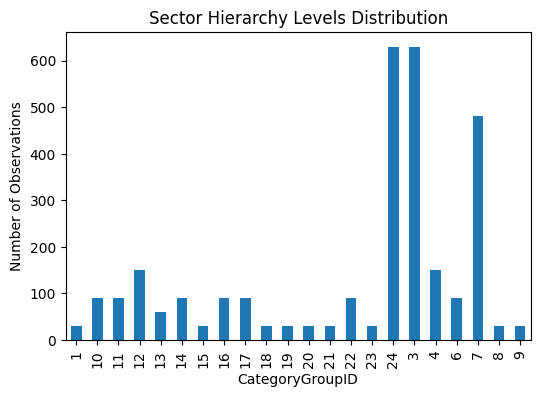

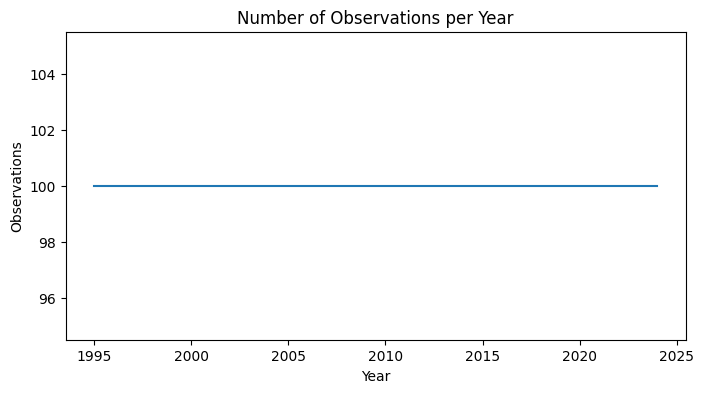

In [9]:
# --------------------------------
# Dataset overview
# --------------------------------

import matplotlib.pyplot as plt


# 1. Dataset size
print("Rows:", df_85919NED_clean.shape[0])
print("Columns:", df_85919NED_clean.shape[1])


# 2. Time coverage
print("\nTime coverage:")
print("Start:", df_85919NED_clean["period_enddate"].min())
print("End:", df_85919NED_clean["period_enddate"].max())

print("\nUnique years:")
print(df_85919NED_clean["year"].nunique())


# 3. Sector coverage
print("\nNumber of unique sectors:")
print(df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"].nunique())

print("\nExample sectors:")
print(
    df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"]
    .unique()[:10]
)


# 4. Industry hierarchy levels
print("\nSector hierarchy distribution (CategoryGroupID):")
print(
    df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"]
    .value_counts()
)


# 5. Observations per year
print("\nObservations per year:")
print(
    df_85919NED_clean.groupby("year").size()
)


# 6. Missing values overview
print("\nMissing values per column:")
print(
    df_85919NED_clean
    .isna()
    .sum()
    .sort_values(ascending=False)
)


# 7. Sector hierarchy visualization
plt.figure(figsize=(6,4))

df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"]\
    .value_counts()\
    .sort_index()\
    .plot(kind="bar")

plt.title("Sector Hierarchy Levels Distribution")
plt.xlabel("CategoryGroupID")
plt.ylabel("Number of Observations")

plt.show()


# 8. Observations per year visualization
plt.figure(figsize=(8,4))

df_85919NED_clean.groupby("year").size().plot()

plt.title("Number of Observations per Year")
plt.xlabel("Year")
plt.ylabel("Observations")

plt.show()

#### Dataset Overview — Key Insights

##### Structure
- The dataset contains **3,000 observations and 39 variables**.
- Each observation represents **one industry (SBI 2008) in a specific year**.
- The structure of the dataset is therefore:

**Industry × Year**

---

##### Time Coverage
- The dataset spans **30 years (1995–2024)**.
- Each year contains **exactly 100 sector observations**, indicating **complete yearly coverage with no gaps**.
- The flat line in the *observations per year* chart confirms the **stable structure of the dataset across time**.

---

##### Industry Coverage
- The dataset includes **100 unique industry categories** from the **SBI 2008 classification**.
- These categories include:
  - **Aggregated sectors** (e.g., *A–U All economic activities*)
  - **Main economic sectors** (A–U)
  - **More detailed subsectors**

Because CBS publishes **multiple hierarchy levels**, the dataset contains **nested industry aggregations**.

For analysis we will use:

- **CategoryGroupID = 1** → Total economy (macro-level analysis)
- **CategoryGroupID = 3** → Main sectors A–U (industry comparison)

Using CategoryGroupID = 3 ensures we **avoid double counting sectors**.

---

##### Sector Hierarchy
The hierarchy distribution shows that observations are spread across **multiple aggregation levels**, with the largest counts appearing in **main sector levels and aggregated sector groups**.

This confirms that **sector hierarchy filtering is required during EDA** to ensure valid sector comparisons.

---

##### Missing Values
Missing values follow **clear structural patterns**:

- `quarter` is entirely missing because the dataset contains **annual observations only**.
- Indicators related to **working hours and full-time/part-time jobs** have about **50% missing values**, reflecting that CBS publishes these variables **only for certain sector aggregation levels**.
- Most core indicators (e.g., wages, labour volume, jobs) have **very limited missing data (~60 rows)**.

These missing values are therefore **structural rather than data quality issues**.

---

##### Overall Assessment
This dataset provides a **long historical view of labour market structure across industries**, including information on:

- labour volume
- wages and labour costs
- working hours
- job composition

The **consistent 30-year time coverage and complete yearly observations** make the dataset well suited for analyzing **structural labour market differences across sectors**.

### Sector Size Comparison (Labour Volume)

C:\Users\gebruiker\AppData\Local\Temp\ipykernel_37344\986885660.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("BedrijfstakkenBranchesSBI2008_Title")["Arbeidsjaren"]


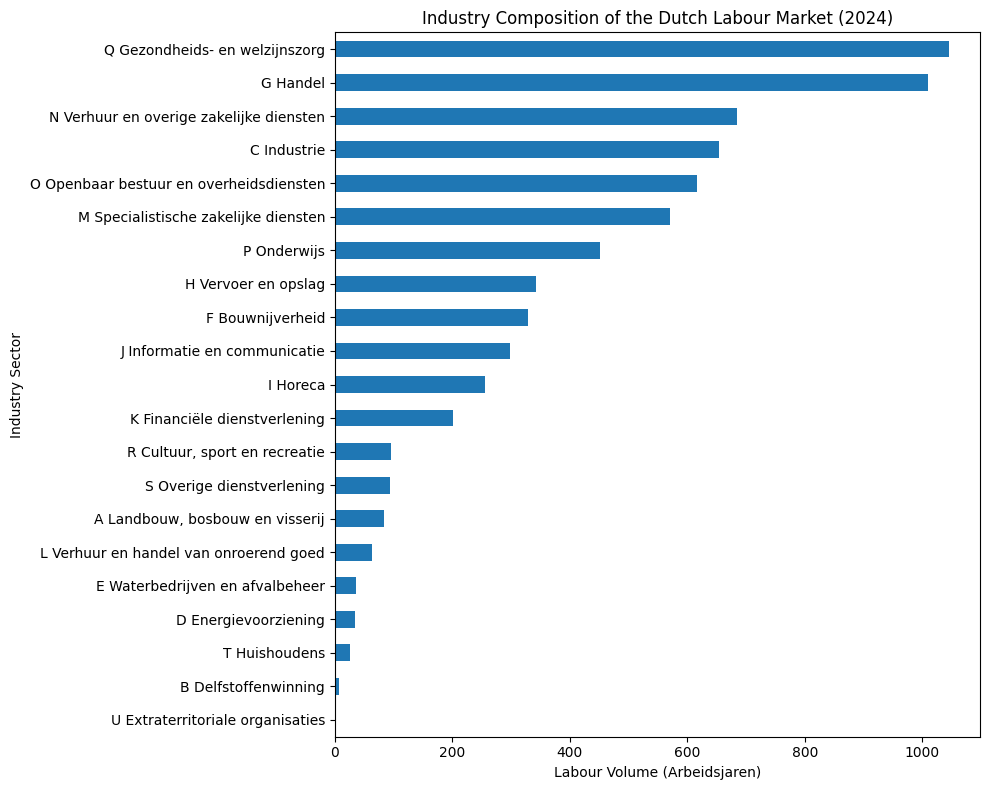

In [23]:
industry_sector = df_85919NED_clean.loc[
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"] == "3") &
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"] != "A-U Alle economische activiteiten") &
    (df_85919NED_clean["year"] == 2024)
].copy()

# remove unused categorical labels
industry_sector["BedrijfstakkenBranchesSBI2008_Title"] = (
    industry_sector["BedrijfstakkenBranchesSBI2008_Title"]
    .cat.remove_unused_categories()
)

sector_size = (
    industry_sector
    .groupby("BedrijfstakkenBranchesSBI2008_Title")["Arbeidsjaren"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

sector_size.plot(kind="barh")

plt.title("Industry Composition of the Dutch Labour Market (2024)")
plt.xlabel("Labour Volume (Arbeidsjaren)")
plt.ylabel("Industry Sector")

plt.tight_layout()
plt.show()

##### Industry composition of the Dutch labour market (2024)

The Dutch labour market is dominated by service sectors. 
Healthcare and welfare (Q) represents the largest share of labour volume, followed by trade (G), business services (N and M), public administration (O), and manufacturing (C). 

Together, these sectors account for a large portion of total employment. In contrast, sectors such as mining (B), utilities (D and E), and agriculture (A) represent relatively small shares of labour volume.

This confirms the strong service-oriented structure of the Dutch economy.

### Sector Employment Evolution (1995–2024)

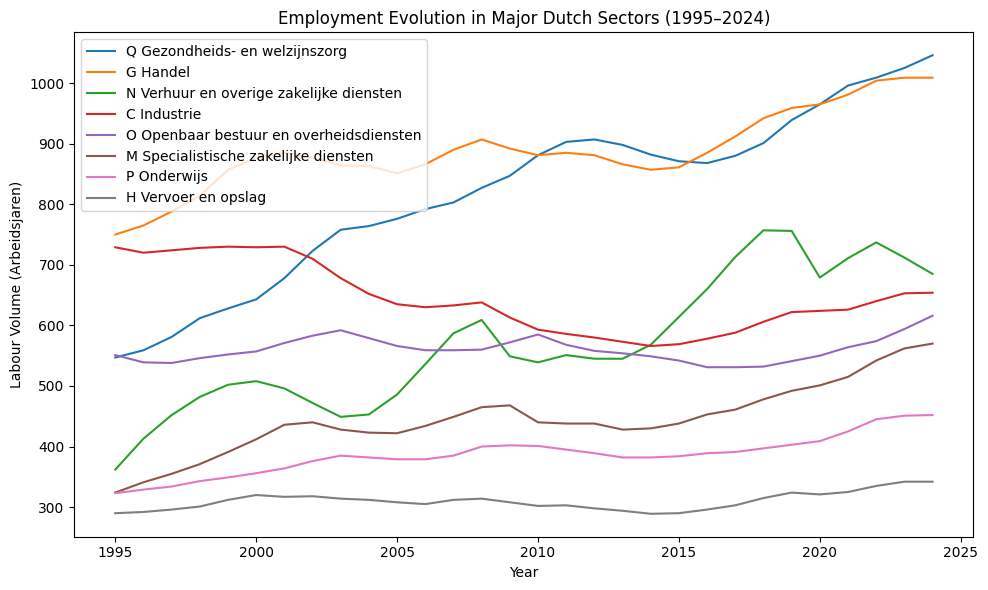

In [24]:
# -----------------------------
# Sector employment evolution
# -----------------------------

# 1. Filter sector level only (A–U)
sector_level = df_85919NED_clean.loc[
    df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"] == "3"
].copy()

# remove unused categorical labels
sector_level["BedrijfstakkenBranchesSBI2008_Title"] = (
    sector_level["BedrijfstakkenBranchesSBI2008_Title"]
    .cat.remove_unused_categories()
)

# remove total economy
sector_level = sector_level.loc[
    sector_level["BedrijfstakkenBranchesSBI2008_Title"] !=
    "A-U Alle economische activiteiten"
]

# 2. Identify largest sectors (based on 2024)
top_sectors = (
    sector_level.loc[sector_level["year"] == 2024]
    .sort_values("Arbeidsjaren", ascending=False)
    ["BedrijfstakkenBranchesSBI2008_Title"]
    .head(8)
)

# 3. Keep only these sectors
sector_trend = sector_level.loc[
    sector_level["BedrijfstakkenBranchesSBI2008_Title"].isin(top_sectors)
]

# 4. Plot
plt.figure(figsize=(10,6))

for sector in top_sectors:
    
    sector_data = sector_trend.loc[
        sector_trend["BedrijfstakkenBranchesSBI2008_Title"] == sector
    ]
    
    plt.plot(
        sector_data["year"],
        sector_data["Arbeidsjaren"],
        label=sector
    )

plt.title("Employment Evolution in Major Dutch Sectors (1995–2024)")
plt.xlabel("Year")
plt.ylabel("Labour Volume (Arbeidsjaren)")
plt.legend()

plt.tight_layout()
plt.show()

##### Sector employment evolution (1995–2024)

The Dutch labour market shows clear structural changes over the past three decades.

Healthcare and welfare (Q) has experienced the strongest and most consistent growth, increasing from roughly 550 thousand labour years in 1995 to over 1 million in 2024, making it the largest sector in the economy. Trade (G) also remains a major employer, though its growth has been more moderate and cyclical.

Business services (N) expanded significantly, particularly after 2015, reflecting the increasing importance of outsourced and flexible service activities in the Dutch economy. Specialist business services (M) and education (P) also show steady long-term growth.

Manufacturing (C) shows a different pattern: employment declined during the early 2000s and only partially recovered afterward, illustrating the gradual structural shift away from traditional industrial employment.

Overall, the figure highlights the transition toward a service-oriented labour market, with healthcare, business services, and public sector activities accounting for a growing share of total employment.

### Average compensation per labour year by sector (2024)

C:\Users\gebruiker\AppData\Local\Temp\ipykernel_37344\3449478200.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("BedrijfstakkenBranchesSBI2008_Title")["BeloningPerArbeidsjaar"]


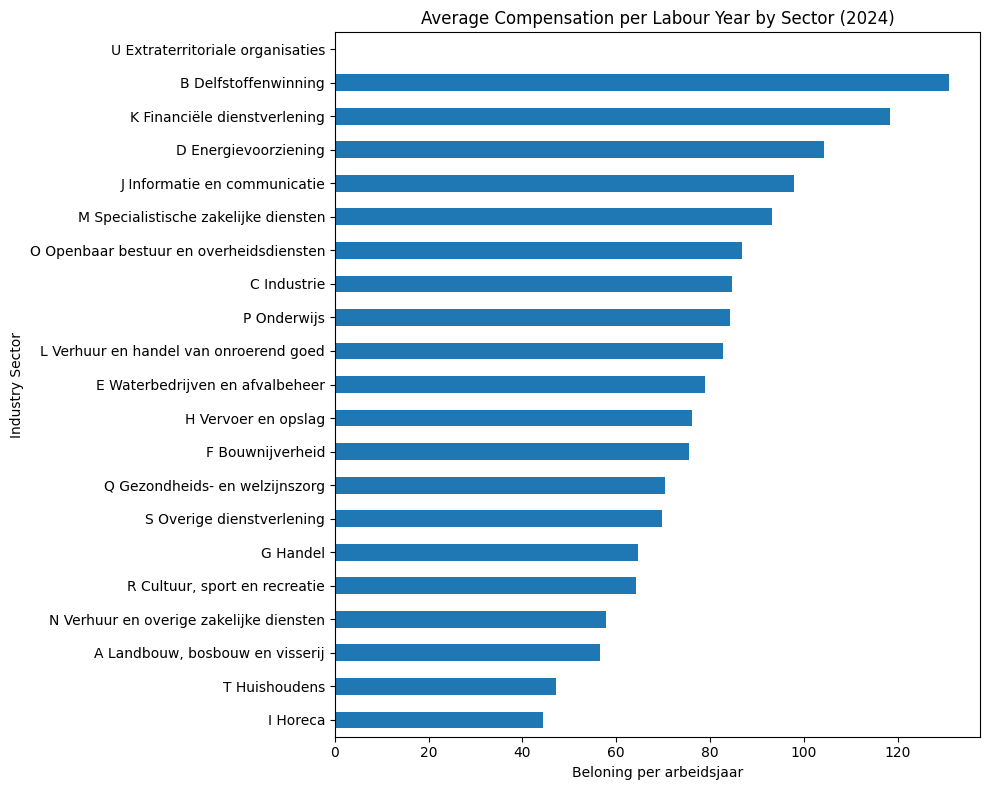

In [25]:
# -----------------------------
# Sector wage comparison
# -----------------------------

# 1. Filter sector level (A–U)
sector_wages = df_85919NED_clean.loc[
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"] == "3") &
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"] != "A-U Alle economische activiteiten") &
    (df_85919NED_clean["year"] == 2024)
].copy()

# remove unused categorical labels
sector_wages["BedrijfstakkenBranchesSBI2008_Title"] = (
    sector_wages["BedrijfstakkenBranchesSBI2008_Title"]
    .cat.remove_unused_categories()
)

# 2. Compute wages per sector
wage_levels = (
    sector_wages
    .groupby("BedrijfstakkenBranchesSBI2008_Title")["BeloningPerArbeidsjaar"]
    .mean()
    .sort_values()
)

# 3. Plot
plt.figure(figsize=(10,8))

wage_levels.plot(kind="barh")

plt.title("Average Compensation per Labour Year by Sector (2024)")
plt.xlabel("Beloning per arbeidsjaar")
plt.ylabel("Industry Sector")

plt.tight_layout()
plt.show()

##### Insight - Average compensation per labour year by sector (2024)

Compensation levels differ substantially across sectors of the Dutch economy. The highest compensation per labour year is observed in mining (B), financial services (K), and energy supply (D). These sectors are typically capital-intensive and require highly specialized skills, which contributes to higher productivity and wages.

Knowledge-intensive service sectors such as information and communication (J) and specialist business services (M) also show relatively high compensation levels. Public sector activities such as public administration (O), education (P), and healthcare (Q) fall in the middle range.

At the lower end of the distribution are hospitality (I), household services (T), and agriculture (A), which generally involve lower productivity levels and a larger share of lower-paid occupations.

Overall, the results highlight significant heterogeneity in wage levels across sectors, reflecting differences in productivity, skill requirements, and capital intensity within the Dutch labour market.

### Sector size vs compensation (2024)

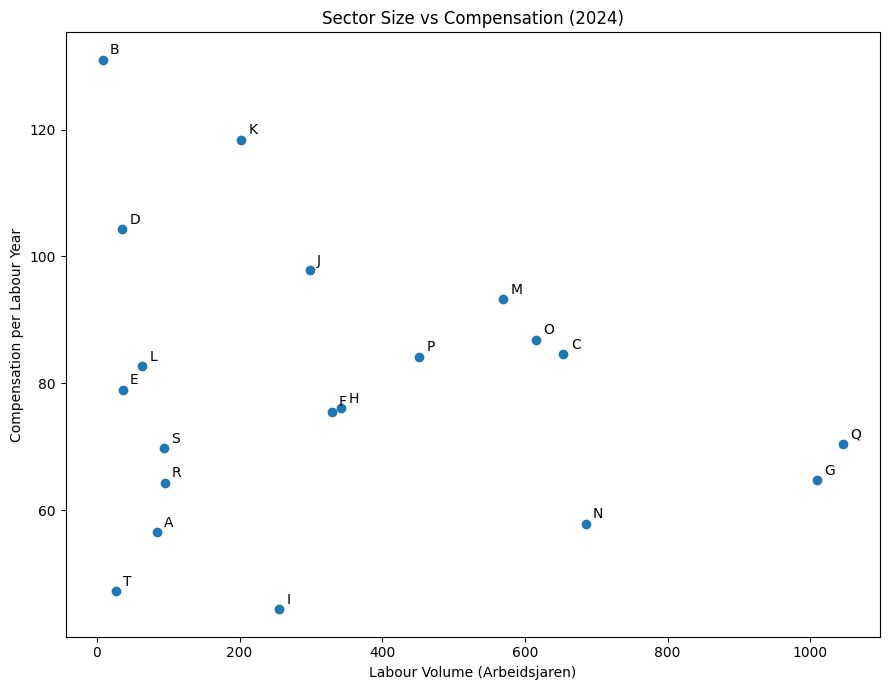

In [27]:
# -----------------------------
# Sector size vs compensation
# -----------------------------

sector_scatter = df_85919NED_clean.loc[
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"] == "3") &
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"] != "A-U Alle economische activiteiten") &
    (df_85919NED_clean["year"] == 2024)
].copy()

# remove unused categorical labels
sector_scatter["BedrijfstakkenBranchesSBI2008_Title"] = (
    sector_scatter["BedrijfstakkenBranchesSBI2008_Title"]
    .cat.remove_unused_categories()
)

sector_metrics = sector_scatter[[
    "BedrijfstakkenBranchesSBI2008_Title",
    "Arbeidsjaren",
    "BeloningPerArbeidsjaar"
]].copy()


plt.figure(figsize=(9,7))

x = sector_metrics["Arbeidsjaren"]
y = sector_metrics["BeloningPerArbeidsjaar"]

plt.scatter(x, y)

# label offset
x_offset = (x.max() - x.min()) * 0.01
y_offset = (y.max() - y.min()) * 0.01

for i, sector in enumerate(sector_metrics["BedrijfstakkenBranchesSBI2008_Title"]):

    label = sector.split(" ")[0]  # sector letter (A,B,C...)

    plt.text(
        x.iloc[i] + x_offset,
        y.iloc[i] + y_offset,
        label,
        fontsize=10
    )

plt.title("Sector Size vs Compensation (2024)")
plt.xlabel("Labour Volume (Arbeidsjaren)")
plt.ylabel("Compensation per Labour Year")

plt.tight_layout()
plt.show()

##### Sector size vs compensation

Comparing sector employment size with average compensation per labour year highlights clear structural differences across industries.

Large service sectors dominate the Dutch labour market in terms of employment. Healthcare and welfare (Q) and trade (G) employ the largest number of workers but offer mid-range compensation levels. Business services (N) also represent a large share of employment but have relatively lower compensation compared with other knowledge-intensive sectors.

High-compensation sectors include mining (B), financial services (K), energy supply (D), and information and communication (J). These industries employ comparatively fewer workers but offer significantly higher compensation per labour year.

Lower-compensation sectors include hospitality (I), households (T), and agriculture (A), which combine smaller employment levels with relatively low compensation.

Overall, the Dutch labour market shows a clear separation between large service-oriented sectors with moderate wages and smaller, capital- or knowledge-intensive sectors with higher compensation levels.

### Part-time vs Full-time structure by sector (2024)

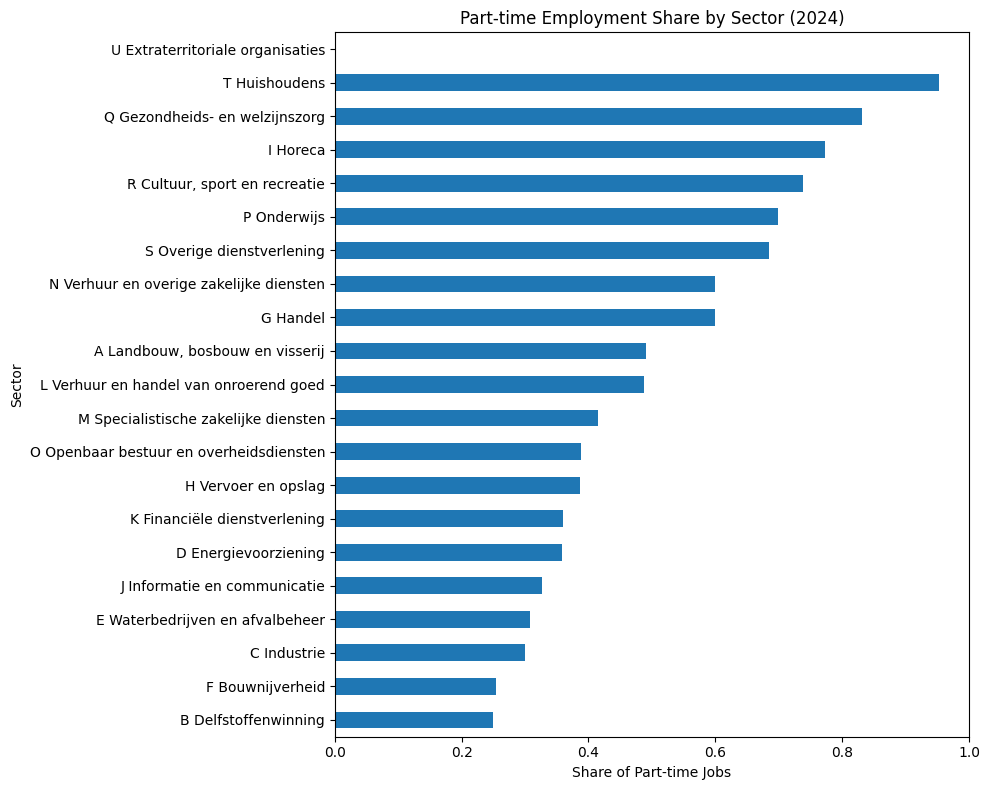

In [28]:
# -----------------------------
# Full-time vs part-time structure by sector
# -----------------------------

sector_hours = df_85919NED_clean.loc[
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"] == "3") &
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"] != "A-U Alle economische activiteiten") &
    (df_85919NED_clean["year"] == 2024)
].copy()

# remove unused categorical labels
sector_hours["BedrijfstakkenBranchesSBI2008_Title"] = (
    sector_hours["BedrijfstakkenBranchesSBI2008_Title"]
    .cat.remove_unused_categories()
)

# calculate part-time share
sector_hours["parttime_share"] = (
    sector_hours["deeltijdbanen_totaal"] /
    sector_hours["banen_totaal"]
)

parttime_share = (
    sector_hours
    .set_index("BedrijfstakkenBranchesSBI2008_Title")["parttime_share"]
    .sort_values()
)

plt.figure(figsize=(10,8))

parttime_share.plot(kind="barh")

plt.title("Part-time Employment Share by Sector (2024)")
plt.xlabel("Share of Part-time Jobs")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

##### Part-time employment structure by sector

The share of part-time employment varies significantly across sectors in the Dutch labour market. Household services (T), healthcare and welfare (Q), hospitality (I), and culture and recreation (R) show the highest proportions of part-time jobs, often exceeding 70–90% of total employment. These sectors typically rely on flexible working schedules and include many service-oriented occupations.

In contrast, sectors such as construction (F), manufacturing (C), mining (B), and energy supply (D) exhibit much lower shares of part-time work, indicating a stronger reliance on full-time employment arrangements. Knowledge-intensive sectors such as ICT (J) and finance (K) also show relatively moderate levels of part-time employment.

Overall, the results highlight the strong role of part-time work in the Dutch service economy, particularly in healthcare and hospitality, while production-oriented sectors remain predominantly full-time.

### Sector Productivity Proxy

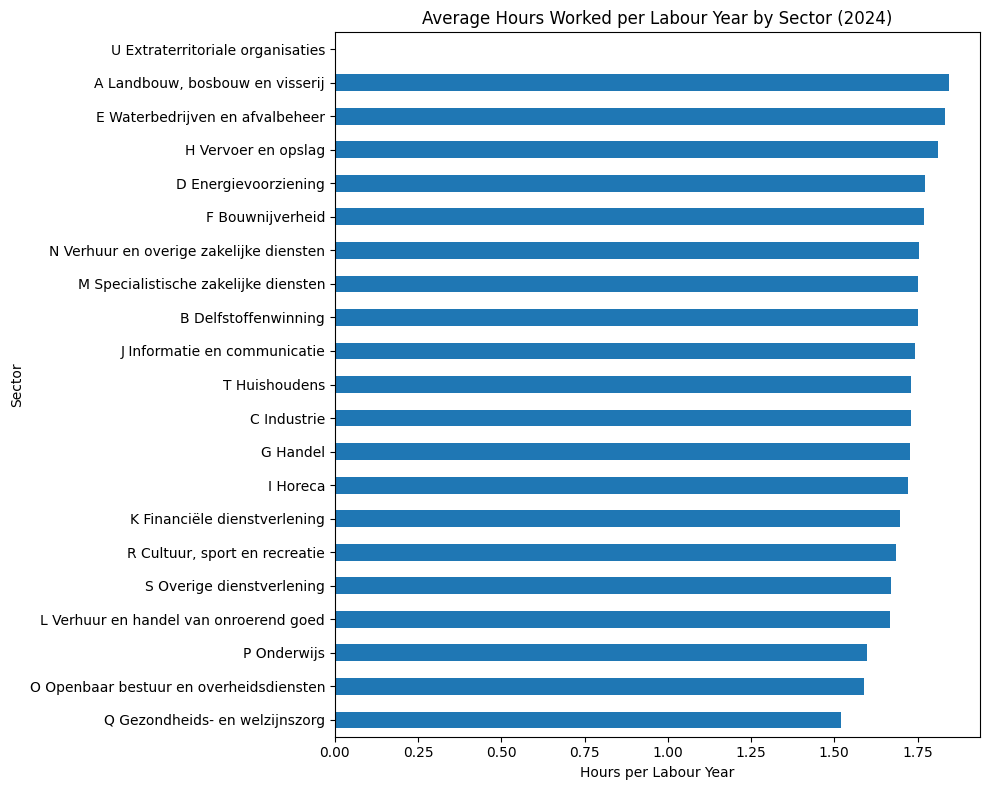

In [29]:
# -----------------------------
# Hours worked per labour year by sector
# -----------------------------

sector_hours = df_85919NED_clean.loc[
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_CategoryGroupID"] == "3") &
    (df_85919NED_clean["BedrijfstakkenBranchesSBI2008_Title"] != "A-U Alle economische activiteiten") &
    (df_85919NED_clean["year"] == 2024)
].copy()

# remove unused categories
sector_hours["BedrijfstakkenBranchesSBI2008_Title"] = (
    sector_hours["BedrijfstakkenBranchesSBI2008_Title"]
    .cat.remove_unused_categories()
)

# calculate hours per labour year
sector_hours["hours_per_labour_year"] = (
    sector_hours["GewerkteUren"] /
    sector_hours["Arbeidsjaren"]
)

hours_sector = (
    sector_hours
    .set_index("BedrijfstakkenBranchesSBI2008_Title")["hours_per_labour_year"]
    .sort_values()
)

plt.figure(figsize=(10,8))

hours_sector.plot(kind="barh")

plt.title("Average Hours Worked per Labour Year by Sector (2024)")
plt.xlabel("Hours per Labour Year")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

##### Working hours intensity by sector

The average number of hours worked per labour year varies across sectors but generally ranges between roughly 1500 and 1800 hours per year. Sectors such as agriculture, transport, and energy exhibit relatively high working hours per labour year, reflecting a stronger reliance on full-time employment and longer working schedules.

In contrast, sectors such as healthcare, education, and public administration show lower hours per labour year. This is consistent with the higher prevalence of part-time work in these sectors, particularly in healthcare and education.

Overall, the results reinforce the structural differences in working time arrangements across sectors of the Dutch labour market.

# Summary and Key Insights

The exploratory analysis of CBS dataset 85919NED provides several insights into the structure of the Dutch labour market across industries.

First, employment is highly concentrated in a few large service sectors. Healthcare and welfare, trade, and business services account for a substantial share of total labour volume, reflecting the dominant role of the service economy.

Second, compensation levels vary significantly across industries. Financial services, energy supply, and mining exhibit the highest compensation per labour year, while sectors such as hospitality, agriculture, and household services show comparatively lower labour costs.

Third, the analysis highlights strong differences in working time arrangements across sectors. Part-time employment is particularly common in healthcare, hospitality, and education, while sectors such as construction, manufacturing, and transport rely more heavily on full-time employment.

Finally, the comparison of working hours per labour year confirms these structural differences, with sectors characterized by higher part-time shares also exhibiting lower average working hours.

Overall, the results illustrate the diversity of labour market structures across industries and provide valuable context for understanding sector-specific labour dynamics in the Netherlands.

## Potential Use for Sick Leave Prediction

Although this table does not contain direct information on sickness absence, it provides important structural indicators of the labour market that can be useful when combined with other datasets in a predictive modelling context.

Several variables from this table may serve as useful features when analysing sick leave patterns across sectors:

- **Labour volume (Arbeidsjaren)** – indicates the size of employment in each sector and may help explain the total number of sickness cases.
- **Compensation per labour year** – can act as a proxy for sector wage levels and job quality, which may influence sickness absence behaviour.
- **Part-time employment share** – sectors with high shares of part-time work may exhibit different sickness patterns compared with predominantly full-time sectors.
- **Working hours per labour year** – provides insight into labour intensity and potential workload differences across sectors.

When combined with datasets containing sickness absence indicators, these sector-level characteristics may help explain structural differences in sick leave risk across industries. For example, sectors with physically demanding jobs, high working hours, or large employment volumes may display different absence patterns than knowledge-intensive sectors.

These features can therefore serve as contextual variables in predictive models aimed at understanding and forecasting sickness absence.